In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [2]:
# Uninstall existing PyTorch packages
!pip uninstall torch torchvision torchaudio -y

# Clear pip cache (optional but helps with corrupted installs)
!pip cache purge

# Reinstall PyTorch, torchvision, torchaudio with CUDA 12.1 support
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121

Found existing installation: torch 2.10.0+cu128
Uninstalling torch-2.10.0+cu128:
  Successfully uninstalled torch-2.10.0+cu128
Found existing installation: torchvision 0.25.0+cu128
Uninstalling torchvision-0.25.0+cu128:
  Successfully uninstalled torchvision-0.25.0+cu128
Found existing installation: torchaudio 2.10.0+cu128
Uninstalling torchaudio-2.10.0+cu128:
  Successfully uninstalled torchaudio-2.10.0+cu128
Files removed: 0
Looking in indexes: https://download.pytorch.org/whl/cu121
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 780.4/780.4 MB 2.1 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.3/7.3 MB 2.9 MB/s eta 0:00:000:00:010:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.4/3.4 MB 87.5 MB/s eta 0:00:00:00:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 23.7/23.7 MB 74.2 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 823.6/823.6 kB 43.8 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.1/14.1 MB 91.4 MB/s eta 

In [3]:
#IMPORTS
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
from tqdm import tqdm
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

from transformers import (
    ViTForImageClassification,
    DeiTForImageClassification,
    SwinForImageClassification
)

In [4]:
#DATASET PATH AND TRANSFORMS (FIXED)

DATASET_PATH = "/kaggle/input/datasets/mrkk8565/ship-classification/FGSC-23"

train_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(15),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

test_transforms = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

train_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "train"),
    transform=train_transforms
)

test_dataset = datasets.ImageFolder(
    os.path.join(DATASET_PATH, "test"),
    transform=test_transforms
)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

num_classes = len(train_dataset.classes)
device = "cuda" if torch.cuda.is_available() else "cpu"

print("Number of classes:", num_classes)

Number of classes: 23


In [6]:
#LOAD ViT-B/16

vit_b16 = ViTForImageClassification.from_pretrained(
    "google/vit-base-patch16-224-in21k",
    num_labels=num_classes
)

vit_b16.to(device)

# Freeze backbone (train classifier first)
for param in vit_b16.vit.parameters():
    param.requires_grad = False

criterion = nn.CrossEntropyLoss()
optimizer = optim.AdamW(vit_b16.parameters(), lr=1e-3)

Loading weights:   0%|          | 0/198 [00:00<?, ?it/s]

ViTForImageClassification LOAD REPORT from: google/vit-base-patch16-224-in21k
Key                 | Status     | 
--------------------+------------+-
pooler.dense.bias   | UNEXPECTED | 
pooler.dense.weight | UNEXPECTED | 
classifier.bias     | MISSING    | 
classifier.weight   | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


In [ ]:
#TRAIN ViT-B/16

from sklearn.metrics import accuracy_score

EPOCHS_PHASE1 = 2   # classifier only
EPOCHS_PHASE2 = 8   # fine-tune full model
total_epochs = EPOCHS_PHASE1 + EPOCHS_PHASE2

for epoch in range(total_epochs):

    vit_b16.train()
    running_loss = 0
    all_preds = []
    all_labels = []

    # Unfreeze backbone after phase 1
    if epoch == EPOCHS_PHASE1:
        print("Unfreezing backbone...")
        for param in vit_b16.vit.parameters():
            param.requires_grad = True
        optimizer = optim.AdamW(vit_b16.parameters(), lr=2e-5)

    for images, labels in tqdm(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = vit_b16(images).logits
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        preds = outputs.argmax(dim=1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

    epoch_loss = running_loss / len(train_dataset)
    epoch_acc = accuracy_score(all_labels, all_preds)

    print(f"Epoch [{epoch+1}/{total_epochs}] "
          f"Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

100%|██████████| 204/204 [01:57<00:00,  1.74it/s]


Epoch [1/10] Loss: 0.2021 | Accuracy: 0.9764


100%|██████████| 204/204 [01:57<00:00,  1.74it/s]


Epoch [2/10] Loss: 0.2051 | Accuracy: 0.9702
Unfreezing backbone...


100%|██████████| 204/204 [02:02<00:00,  1.66it/s]


...

100%|██████████| 204/204 [02:02<00:00,  1.67it/s]


Epoch [8/10] Loss: 0.0467 | Accuracy: 0.9939


100%|██████████| 204/204 [02:02<00:00,  1.67it/s]


Epoch [9/10] Loss: 0.0303 | Accuracy: 0.9966


 79%|███████▉  | 162/204 [01:37<00:25,  1.66it/s]

In [22]:
#EVALUATE ViT-B/16

vit_b16.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = vit_b16(images).logits
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print("📊 ViT-B/16 RESULTS")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("Confusion Matrix:\n", cm)

📊 ViT-B/16 RESULTS
Accuracy  : 0.8604
Precision : 0.8733
Recall    : 0.8604
F1 Score  : 0.8623
Confusion Matrix:
 [[ 81   0   5   0   0   4   0   0   0   5   0   0   1   1   0   0   0   0
    0   0   0   0   0]
 [  0  32   0   0   0   0   0   0   0   0   0   0   1   0   0   0   0   0
    1   0   0   0   0]
 [  2   0  43   0   1   1   0   0   0   0   0   0   0   0   0   0   0   0
    1   0   0   0   0]
 [  0   0   0  10   0   0   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  0   0   0   0  25   4   0   0   0   0   0   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  2   0   0   0   4  36   0   0   0   2   1   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  0   0   0   0   0   0  16   0   0   3   0   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  0   0   0   0   0   0   0  13   0   1   0   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  24   0   0   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  0   0   1

In [23]:
deit_model = DeiTForImageClassification.from_pretrained(
    "facebook/deit-base-patch16-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True,
    use_safetensors=True  # <--- Safetensors avoids torch version issue
)

deit_model.to(device)

# ---------------- LOSS AND OPTIMIZER ----------------
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(deit_model.parameters(), lr=3e-5)

# ---------------- TRAINING LOOP ----------------
epochs = 10
train_losses = []
val_accuracies = []

for epoch in range(epochs):
    deit_model.train()
    running_loss = 0.0
    
    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = deit_model(images).logits
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
    
    epoch_loss = running_loss / len(train_loader)
    train_losses.append(epoch_loss)
    
    # ---------------- VALIDATION ----------------
    deit_model.eval()
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = deit_model(images).logits
            preds = torch.argmax(outputs, dim=1)
            
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    acc = accuracy_score(all_labels, all_preds)
    val_accuracies.append(acc)
    
    print(f"DeiT-Base - Epoch {epoch+1}/{epochs}")
    print(f"Training Loss: {epoch_loss:.4f}")
    print(f"Validation Accuracy: {acc:.4f}")
    print("-"*40)

You are using a model of type vit to instantiate a model of type deit. This is not supported for all configurations of models and can yield errors.


Loading weights:   0%|          | 0/2 [00:00<?, ?it/s]

DeiTForImageClassification LOAD REPORT from: facebook/deit-base-patch16-224
Key                                                          | Status     |                                                                                         
-------------------------------------------------------------+------------+-----------------------------------------------------------------------------------------
vit.encoder.layer.{0...11}.layernorm_before.weight           | UNEXPECTED |                                                                                         
vit.encoder.layer.{0...11}.attention.attention.query.bias    | UNEXPECTED |                                                                                         
vit.encoder.layer.{0...11}.attention.attention.key.weight    | UNEXPECTED |                                                                                         
vit.encoder.layer.{0...11}.attention.attention.value.weight  | UNEXPECTED |                        

DeiT-Base - Epoch 1/10
Training Loss: 2.7561
Validation Accuracy: 0.2257
----------------------------------------
DeiT-Base - Epoch 2/10
Training Loss: 2.3928
Validation Accuracy: 0.2755
----------------------------------------
DeiT-Base - Epoch 3/10
Training Loss: 2.1794
Validation Accuracy: 0.2913
----------------------------------------
DeiT-Base - Epoch 4/10
Training Loss: 2.0364
Validation Accuracy: 0.3240
----------------------------------------
DeiT-Base - Epoch 5/10
Training Loss: 1.9454
Validation Accuracy: 0.3447
----------------------------------------
DeiT-Base - Epoch 6/10
Training Loss: 1.8458
Validation Accuracy: 0.3689
----------------------------------------
DeiT-Base - Epoch 7/10
Training Loss: 1.7613
Validation Accuracy: 0.3592
----------------------------------------
DeiT-Base - Epoch 8/10
Training Loss: 1.6943
Validation Accuracy: 0.3859
----------------------------------------
DeiT-Base - Epoch 9/10
Training Loss: 1.5929
Validation Accuracy: 0.4005
---------------

In [24]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

# EVALUATE DeiT-Base

deit_base.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = deit_base(images).logits
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print("📊 DeiT-Base RESULTS")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("Confusion Matrix:\n", cm)

📊 DeiT-Base RESULTS
Accuracy  : 0.6893
Precision : 0.7256
Recall    : 0.6893
F1 Score  : 0.6617
Confusion Matrix:
 [[ 90   0   3   0   0   0   0   0   0   1   1   0   2   0   0   0   0   0
    0   0   0   0   0]
 [  0  28   0   0   0   0   0   0   0   0   0   0   3   0   0   0   0   0
    0   0   0   3   0]
 [  5   0  39   0   1   0   0   0   0   0   0   0   3   0   0   0   0   0
    0   0   0   0   0]
 [  0   0   0   0   0   0   4   4   0   0   0   0   0   0   0   0   1   0
    1   0   0   0   0]
 [  1   0   0   0  23   3   0   0   0   0   0   1   0   1   0   0   0   0
    0   0   0   0   0]
 [  7   0   0   0   4  15   0   0   0   4   1   4   4   4   0   0   0   2
    0   0   0   0   0]
 [  2   0   0   0   0   0  16   0   0   0   1   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  0   0   0   0   0   0   0  13   0   0   0   0   1   0   0   0   0   0
    0   0   0   0   0]
 [  0   0   0   0   0   0   0   0  24   0   0   0   0   0   0   0   0   0
    0   0   0   0   0]
 [  7   0   

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


In [25]:
from transformers import SwinForImageClassification

swin_tiny = SwinForImageClassification.from_pretrained(
    "microsoft/swin-tiny-patch4-window7-224",
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)

swin_tiny.to(device)

Loading weights:   0%|          | 0/233 [00:00<?, ?it/s]

SwinForImageClassification LOAD REPORT from: microsoft/swin-tiny-patch4-window7-224
Key               | Status   |                                                                                         
------------------+----------+-----------------------------------------------------------------------------------------
classifier.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000, 768]) vs model:torch.Size([23, 768])
classifier.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([1000]) vs model:torch.Size([23])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


SwinForImageClassification(
  (swin): SwinModel(
    (embeddings): SwinEmbeddings(
      (patch_embeddings): SwinPatchEmbeddings(
        (projection): Conv2d(3, 96, kernel_size=(4, 4), stride=(4, 4))
      )
      (norm): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): SwinEncoder(
      (layers): ModuleList(
        (0): SwinStage(
          (blocks): ModuleList(
            (0): SwinLayer(
              (layernorm_before): LayerNorm((96,), eps=1e-05, elementwise_affine=True)
              (attention): SwinAttention(
                (self): SwinSelfAttention(
                  (query): Linear(in_features=96, out_features=96, bias=True)
                  (key): Linear(in_features=96, out_features=96, bias=True)
                  (value): Linear(in_features=96, out_features=96, bias=True)
                  (dropout): Dropout(p=0.0, inplace=False)
                )
                (output): SwinSelfOutput(
        

In [26]:
# TRAIN Swin-Tiny

optimizer = torch.optim.AdamW(swin_tiny.parameters(), lr=3e-5)
criterion = torch.nn.CrossEntropyLoss()

num_epochs = 10 

for epoch in range(num_epochs):
    swin_tiny.train()
    
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        outputs = swin_tiny(images).logits
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / len(train_loader)
    epoch_acc = correct / total

    print(f"Swin-Tiny - Epoch [{epoch+1}/{num_epochs}] "
          f"Loss: {epoch_loss:.4f} | Accuracy: {epoch_acc:.4f}")

Swin-Tiny - Epoch [1/10] Loss: 1.7171 | Accuracy: 0.4803
Swin-Tiny - Epoch [2/10] Loss: 0.6386 | Accuracy: 0.8053
Swin-Tiny - Epoch [3/10] Loss: 0.3984 | Accuracy: 0.8738
Swin-Tiny - Epoch [4/10] Loss: 0.2432 | Accuracy: 0.9205
Swin-Tiny - Epoch [5/10] Loss: 0.1581 | Accuracy: 0.9530
Swin-Tiny - Epoch [6/10] Loss: 0.1339 | Accuracy: 0.9598
Swin-Tiny - Epoch [7/10] Loss: 0.0886 | Accuracy: 0.9742
Swin-Tiny - Epoch [8/10] Loss: 0.0708 | Accuracy: 0.9822
Swin-Tiny - Epoch [9/10] Loss: 0.0535 | Accuracy: 0.9862
Swin-Tiny - Epoch [10/10] Loss: 0.0744 | Accuracy: 0.9797


In [27]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
# EVALUATE Swin-Tiny

swin_tiny.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels in test_loader:
        images, labels = images.to(device), labels.to(device)

        outputs = swin_tiny(images).logits
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

acc = accuracy_score(all_labels, all_preds)
prec = precision_score(all_labels, all_preds, average='weighted')
rec = recall_score(all_labels, all_preds, average='weighted')
f1 = f1_score(all_labels, all_preds, average='weighted')
cm = confusion_matrix(all_labels, all_preds)

print("📊 Swin-Tiny RESULTS")
print(f"Accuracy  : {acc:.4f}")
print(f"Precision : {prec:.4f}")
print(f"Recall    : {rec:.4f}")
print(f"F1 Score  : {f1:.4f}")
print("Confusion Matrix:\n", cm)

📊 Swin-Tiny RESULTS
Accuracy  : 0.8507
Precision : 0.8677
Recall    : 0.8507
F1 Score  : 0.8546
Confusion Matrix:
 [[77  0  4  0  0  2  0  0  0  4  0  4  0  4  0  0  0  1  1  0  0  0  0]
 [ 0 30  0  0  0  1  0  0  0  0  0  0  1  0  0  0  0  0  1  0  0  1  0]
 [ 1  0 44  0  2  1  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0 10  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0 26  2  0  0  0  0  0  0  0  1  0  0  0  0  0  0  0  0  0]
 [ 1  0  1  0  1 32  0  0  0  4  0  1  2  3  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0 16  0  0  2  1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0 12  0  1  1  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0 24  0  0  0  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  1  9  0  0 55  1  2  0  1  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  0  0  0  9 22  0  0  0  0  0  0  0  2  0  0  0  0]
 [ 1  0  0  0  0  0  0  0  0  2  0 17  0  0  0  0  0  0  0  0  0  0  0]
 [ 0  0  0  0  0  0  

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


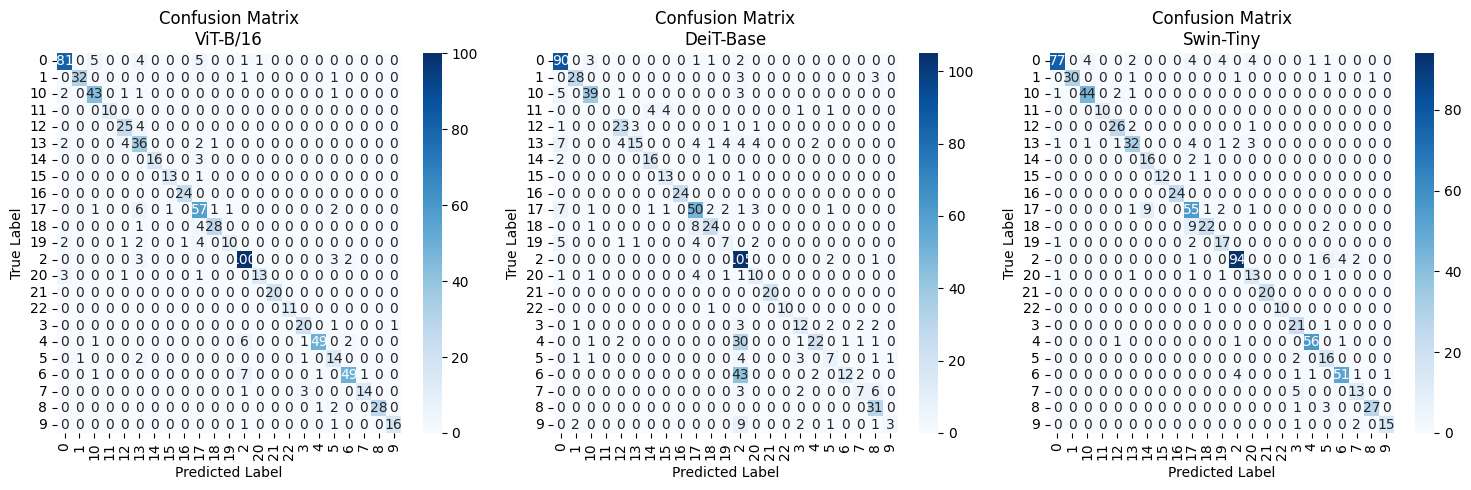

Metrics Comparison Table:


,Accuracy,Precision,Recall,F1
ViT-B/16,0.860437,0.873338,0.860437,0.862303
DeiT-Base,0.689320,0.725553,0.689320,0.661718
Swin-Tiny,0.850728,0.867750,0.850728,0.854572


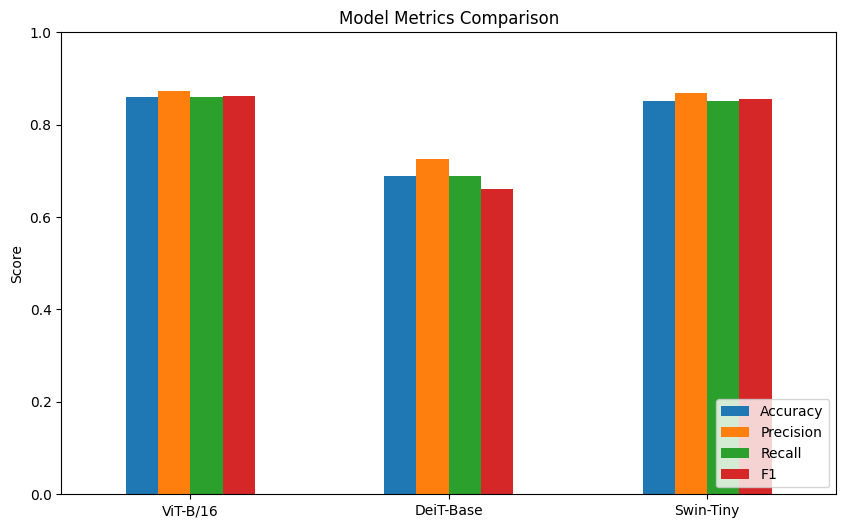

In [28]:
# ==============================
# FINAL VISUALIZATION & COMPARISON WITH PLOTS
# ==============================

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

class_names = test_dataset.classes  # make sure test_dataset is defined

# Models to evaluate
models = {
    "ViT-B/16": vit_b16,
    "DeiT-Base": deit_base,
    "Swin-Tiny": swin_tiny
}

results = {}

# Evaluate models and store metrics + confusion matrices
for name, model in models.items():
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for images, labels in test_loader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images).logits
            preds = outputs.argmax(dim=1)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    acc = accuracy_score(all_labels, all_preds)
    prec = precision_score(all_labels, all_preds, average='weighted')
    rec = recall_score(all_labels, all_preds, average='weighted')
    f1 = f1_score(all_labels, all_preds, average='weighted')
    cm = confusion_matrix(all_labels, all_preds)

    results[name] = {
        "accuracy": acc,
        "precision": prec,
        "recall": rec,
        "f1": f1,
        "cm": cm
    }

# ==============================
# Plot confusion matrices side by side
# ==============================
fig, axes = plt.subplots(1, len(models), figsize=(5*len(models), 5))
if len(models) == 1:
    axes = [axes]

for ax, (name, res) in zip(axes, results.items()):
    sns.heatmap(res["cm"], annot=True, fmt='d', cmap='Blues',
                xticklabels=class_names, yticklabels=class_names, ax=ax)
    ax.set_xlabel("Predicted Label")
    ax.set_ylabel("True Label")
    ax.set_title(f"Confusion Matrix\n{name}")

plt.tight_layout()
plt.show()

# ==============================
# Metrics comparison plot
# ==============================
metrics_df = pd.DataFrame({
    m: {"Accuracy": results[m]["accuracy"],
        "Precision": results[m]["precision"],
        "Recall": results[m]["recall"],
        "F1": results[m]["f1"]}
    for m in results
}).T

print("Metrics Comparison Table:")
display(metrics_df)

# Bar plot for metrics
metrics_df.plot(kind='bar', figsize=(10,6))
plt.title("Model Metrics Comparison")
plt.ylabel("Score")
plt.ylim(0,1)
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.show()